### ARIMA Time Series Modeling
By Stephanie Nguyen

### A1. Research Question 

How can ARIMA time series forecasting be applied to generate reliable short-term revenue predictions for telecom companies using two years of historical revenue data?

### A2. Objectives or Goals

The goal of this time series analysis is to analyze the historical patterns and trends in telecom revenue data and to forecast future revenue.

### B. Summary of Assumptions

The ARIMA model assumes that the time series is stationary, with a constant mean and variance over time. ARIMA also relies on autocorrelation, using past values in the data to help predict future values. 

### PACKAGES AND LIBRARIES LIST

In [ ]:
# !pip install pmdarima

In [ ]:
# Importing all libraries and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ignore warnings
import warnings
warnings.filterwarnings("ignore")

# augmented Dickey-fuller (ADF) test for stationarity
from statsmodels.tsa.stattools import adfuller

# decomposition 
from statsmodels.tsa.seasonal import seasonal_decompose

# train/test split
from sklearn.model_selection import train_test_split

# ACF, PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Power Spectral Density (PSD)
import matplotlib.pyplot as plt
from scipy import signal

# auto_arima tells us if there is seasonality and gives Python's recommendation for p, d, q values 
from pmdarima import auto_arima

# ARIMA model
from statsmodels.tsa.arima.model import ARIMA

# RSME error metric
from sklearn.metrics import mean_squared_error as mse
from math import sqrt


In [ ]:
# Load/import teleco_time_series.csv data set
df = pd.read_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\12. Forecasting Time Series Data with ARIMA (Python)\Data\teleco_time_series.csv")

#### Preview the data set

In [ ]:
# Get the number of rows and columns in the dataframe
df.shape

(731, 2)

In [ ]:
df.columns

Index(['Day', 'Revenue'], dtype='object')

The original time series data set has 731 observations and two columns, Day and Revenue.

In [ ]:
# preview the data
pd.set_option('display.max_columns',None)
# df.head()

,Day,Revenue
0,1,0.000000
1,2,0.000793
2,3,0.825542
3,4,0.320332
4,5,1.082554


In [ ]:
# get overview of columns and data types in dataset
# df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Day      731 non-null    int64  
 1   Revenue  731 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 11.6 KB


#### Data Cleaning
The data set is checked for null and duplicated values during the data cleaning phase.

In [ ]:
# detect null values
df.isnull().sum()

Day        0
Revenue    0
dtype: int64

No missing values were detected from the time series data.

In [ ]:
# get duplicates across all columns
df.duplicated().value_counts()

False    731
Name: count, dtype: int64

No duplicated values were detected from the time series data.

### C1. Line Graph Visualizations
A line graph was plotted to visualize the trend in the time series revenue data.

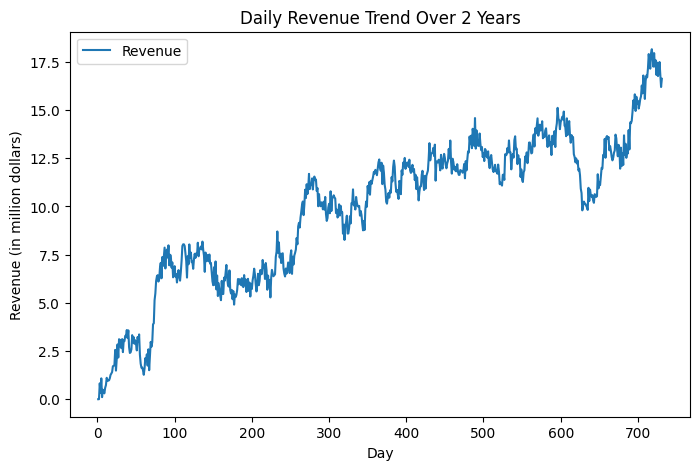

<Figure size 640x480 with 0 Axes>

In [ ]:
# Plot daily revenue trend over 2 years (731 days)
plt.figure(figsize=(8,5))
plt.plot(df['Day'], df['Revenue'], label='Revenue')
plt.xlabel('Day')
plt.ylabel('Revenue (in million dollars)')
plt.title('Daily Revenue Trend Over 2 Years')
plt.legend(loc="upper left")
plt.show()
plt.savefig('Telecom Revenue by Day.png',bbox_inches='tight')

### C2. Time Step Formatting

In [ ]:
# length of the sequence
seq_len = len(df)

# Find gaps in the day column
gaps = df['Day'].diff()

print(f"Time step format: days")
print(f"Length of the sequence: {seq_len} days")
print("Gaps in measurement:", len(gaps[gaps > 1]))

# Identify any gaps where day difference is greater than 1
# print(day_diff[day_diff > 1])  

Time step format: days
Length of the sequence: 731 days
Gaps in measurement: 0


The realization is formatted in daily time steps, showing no observable gaps in the measurements. The data set consists of 731 consecutive days, representing a two-year period.

In [ ]:
ts = pd.Series(df['Revenue'].values, index = df['Day'])
ts.head()

Day
1    0.000000
2    0.000793
3    0.825542
4    0.320332
5    1.082554
dtype: float64

In [ ]:
len(ts)

731

### C3. Stationarity
The augmented Dickey-Fuller test was used to check for stationarity and the p-value is obtained from ADF test results.

In [ ]:
# Augmented Dickey-Fuller test for stationarity mathematically
dickey_fuller_test = adfuller(ts, autolag = 'AIC')
print("Augmented Dickey-Fuller Test Results: ")
print("ADF: ", dickey_fuller_test[0])
print("P-value: ", dickey_fuller_test[1])
print("Number of lags: ", dickey_fuller_test[2])
print("Number of observations used for ADF regression and critical values calc: ", dickey_fuller_test[3])
print("Critical values: ")
for key, val in dickey_fuller_test[4].items():
    print("\t", key,": ",val)

Augmented Dickey-Fuller Test Results: 
ADF:  -1.9246121573101846
P-value:  0.32057281507939595
Number of lags:  1
Number of observations used for ADF regression and critical values calc:  729
Critical values: 
	 1% :  -3.4393520240470554
	 5% :  -2.8655128165959236
	 10% :  -2.5688855736949163


With 730 original data points, the ADF test uses only 729 because it needs to compare each point to the previous one, so the first observation is lost in this process.

The ADF test result shows a p-value of 0.32, which is greater than 0.05, indicating that the data is likely not stationary. <br>
The data must be stationary in order to make the mean and variance constant.

p < 0.05 means that the data is stationary<br>
p > 0.05 means that the data is not stationary<br>

### C4. Data Preparation Steps
The time series data was differenced and stored as a Pandas series, indexed by day. Stationarity was then assessed using the ADF test. Next, the data was split into training and test sets for ARIMA modeling, with the first 641 days used for training and the final 90 days reserved for testing.

In [ ]:
# Use differencing to make the data stationary before applying the time series model
# Perform first-order differencing
diff_ts = pd.Series(ts.diff(), index = ts.index[1:])
# diff_ts.head()

In [ ]:
len(diff_ts)

730

When you difference a time series, the first data point is lost because the process involves subtracting each previous value from the current one. This shifts the entire dataset forward by one time step, causing the differenced series to start at day 2. As a result, the total number of observations decreases from 731 to 730.

#### Augmented Dickey-Fuller (ADF) Test

In [ ]:
# Augmented Dickey-Fuller test for stationarity mathematically
dickey_fuller_test = adfuller(diff_ts, autolag = 'AIC')
print("Augmented Dickey-Fuller Test Results: ")
print("ADF: ", dickey_fuller_test[0])
print("P-value: ", dickey_fuller_test[1])
print("Number of lags: ", dickey_fuller_test[2])
print("Number of observations used for ADF regression and critical values calc: ", dickey_fuller_test[3])
print("Critical values: ")
for key, val in dickey_fuller_test[4].items():
    print("\t", key,": ",val)

Augmented Dickey-Fuller Test Results: 
ADF:  -44.87452719387598
P-value:  0.0
Number of lags:  0
Number of observations used for ADF regression and critical values calc:  729
Critical values: 
	 1% :  -3.4393520240470554
	 5% :  -2.8655128165959236
	 10% :  -2.5688855736949163


Re-running the ADF test on the lagged data produces a p-value below 0.05, confirming that the data has achieved stationarity. The "d" parameter represents the number of differencing steps needed to make the time series stationary; in this case, d=1.

#### Splitting the Data

In [ ]:
# Train all data except the last 90 days and use the 90 days for test
train = ts.iloc[:-90]
test = ts.iloc[-90:]

print('Train:', train.shape)
print('Test:', test.shape)

Train: (641,)
Test: (90,)


In [ ]:
# print('Train:')
# print(train)
# print('Test:')
# print(test)

### C5. Prepared Data Set

In [ ]:
# Export prepared data set
diff_ts.to_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\12. Forecasting Time Series Data with ARIMA (Python)\Outputs\diff_ts.csv",index=False)

In [ ]:
# Export the training and test data set to csv files
pd.Series(train).to_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\12. Forecasting Time Series Data with ARIMA (Python)\Outputs\train.csv",index=False)
pd.Series(test).to_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\12. Forecasting Time Series Data with ARIMA (Python)\Outputs\test.csv",index=False)

### D1. Report Findings and Visualizations

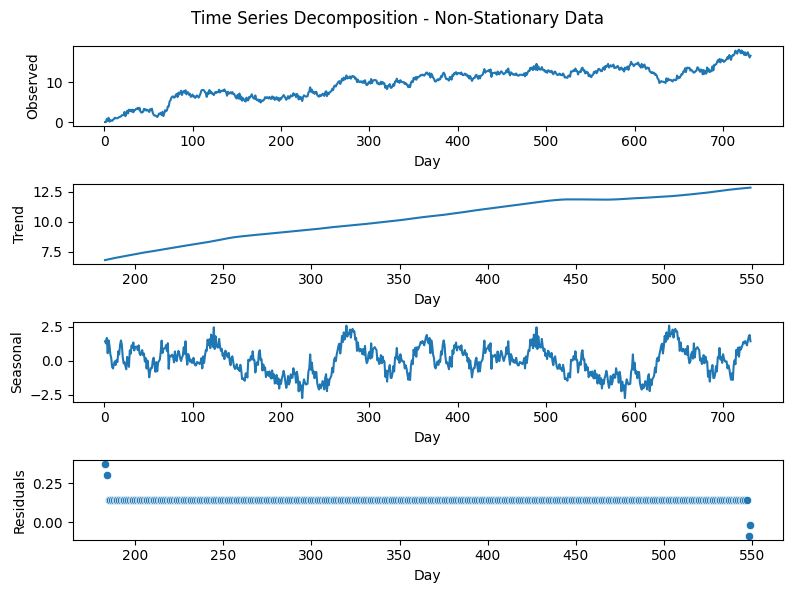

In [ ]:
# Decomposition - before differencing
decomp = seasonal_decompose(ts, model='additive', period = 365)

fig, ax = plt.subplots(4, figsize = (8,6))
plt.suptitle('Time Series Decomposition - Non-Stationary Data')
sns.lineplot(data=decomp.observed, ax=ax[0])
ax[0].set_xlabel('Day')
ax[0].set_ylabel('Observed')
sns.lineplot(data=decomp.trend, ax=ax[1])
ax[1].set_xlabel('Day')
ax[1].set_ylabel('Trend')
sns.lineplot(data=decomp.seasonal, ax=ax[2])
ax[2].set_xlabel('Day')
ax[2].set_ylabel('Seasonal')
sns.scatterplot(data=decomp.resid, ax=ax[3])
ax[3].set_xlabel('Day')
ax[3].set_ylabel('Residuals')

# Adjust layout
plt.tight_layout()
plt.savefig('Time Series Decomposition - Non-Stationary Data.png')

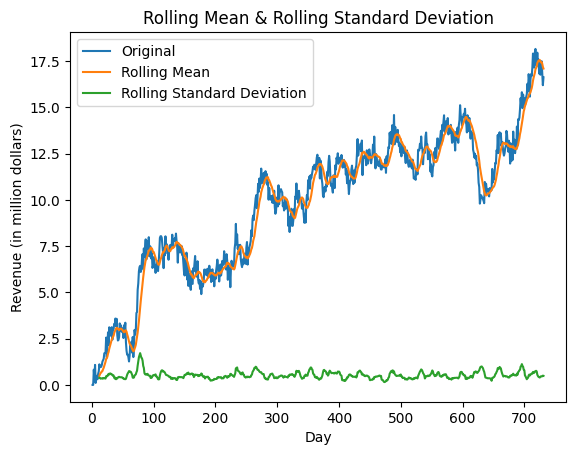

<Figure size 640x480 with 0 Axes>

In [ ]:
# Rolling mean - check for seasonality
rolling_mean = ts.rolling(window=12).mean()
rolling_std = ts.rolling(window=12).std()

original = plt.plot(ts, label = 'Original')
mean = plt.plot(rolling_mean, label = 'Rolling Mean')
std = plt.plot(rolling_std, label = 'Rolling Standard Deviation')
plt.legend(loc='best')
plt.title('Rolling Mean & Rolling Standard Deviation')
plt.xlabel('Day')
plt.ylabel('Revenue (in million dollars)')
plt.show()
plt.savefig('Rolling Mean & Rolling Standard Deviation.png')

The graph shows an upward trend in the rolling mean and a stable rolling standard deviation, indicating a trend rather than seasonality. The lack of cyclical patterns suggests the data likely does not have seasonality, as seasonal data would show regular peaks and troughs in both metrics.

#### Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF)
The ACF is used to determine the moving average (MA) term, represented by "q," while the PACF helps identify the autoregressive (AR) term, represented by "p." Together, they provide the values needed to capture important patterns in the ARIMA model.

#### ACF and PACF of Non-Stationary Data

<Figure size 800x600 with 0 Axes>

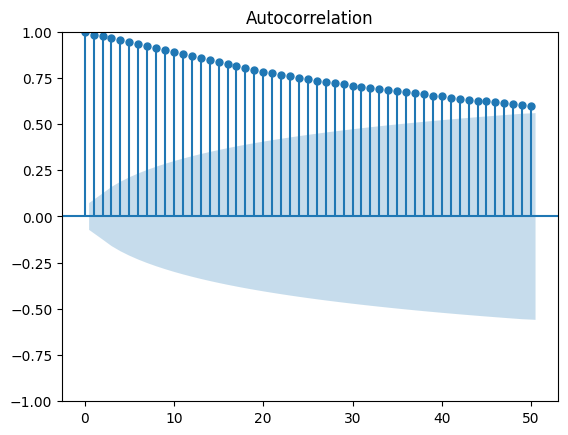

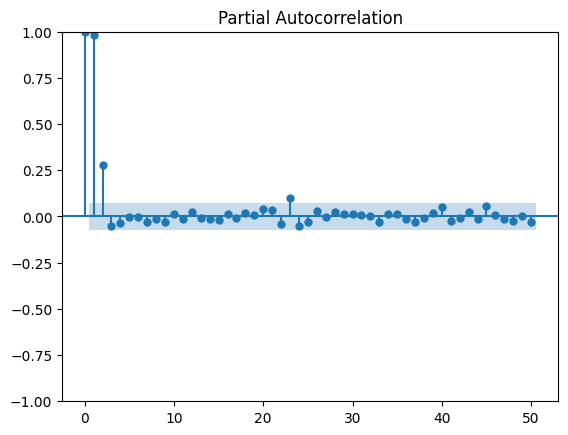

In [ ]:
plt.figure(figsize=(8,6))

# Autocorrelation Function (ACF) - before differencing
plot_acf(ts, lags = 50)

# Partial Autocorrelation Function (PACF) - before differencing
plot_pacf(ts, lags = 50)

plt.show()

#### ACF and PACF of Stationary Data

<Figure size 800x600 with 0 Axes>

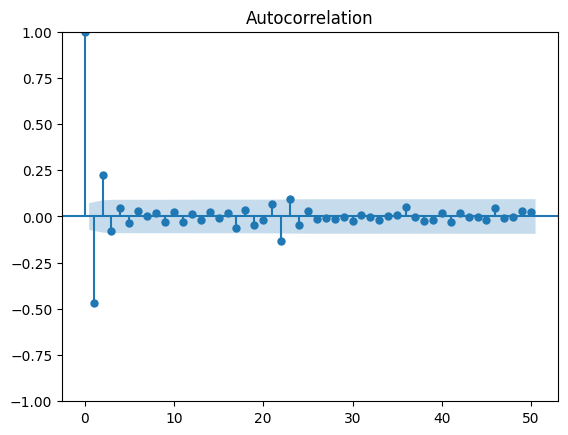

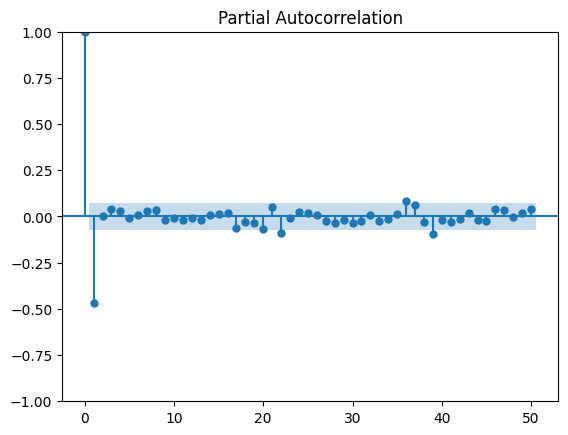

In [ ]:
# Autocorrelation Function (ACF) - after differencing
plt.figure(figsize=(8,6))

plot_acf(diff_ts, lags = 50)

# Partial Autocorrelation Function (PACF) - after differencing
plot_pacf(diff_ts, lags = 50)

plt.show()

#### Spectral Density
Spectral density reveals the underlying signal in a time series and helps identify seasonality by highlighting observable patterns and recurring cycles.

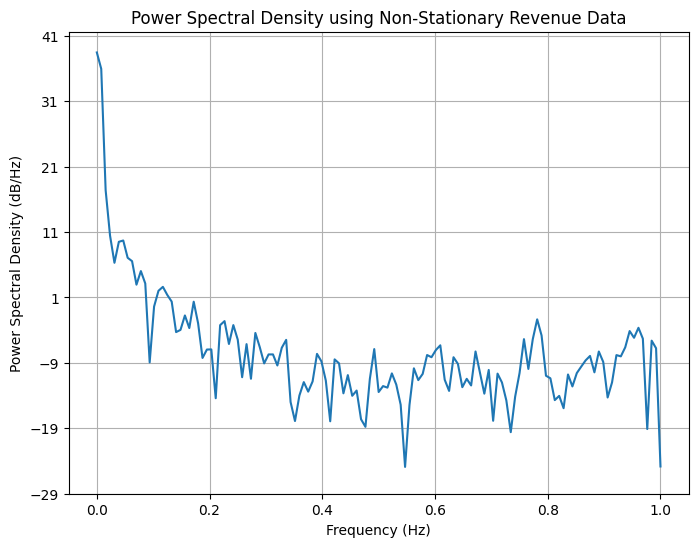

In [ ]:
# Power Spectral Density using the Non-Stationary Revenue Data
plt.figure(figsize=(8,6))
plt.psd(ts)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density (dB/Hz)')
plt.title('Power Spectral Density using Non-Stationary Revenue Data')
plt.show()

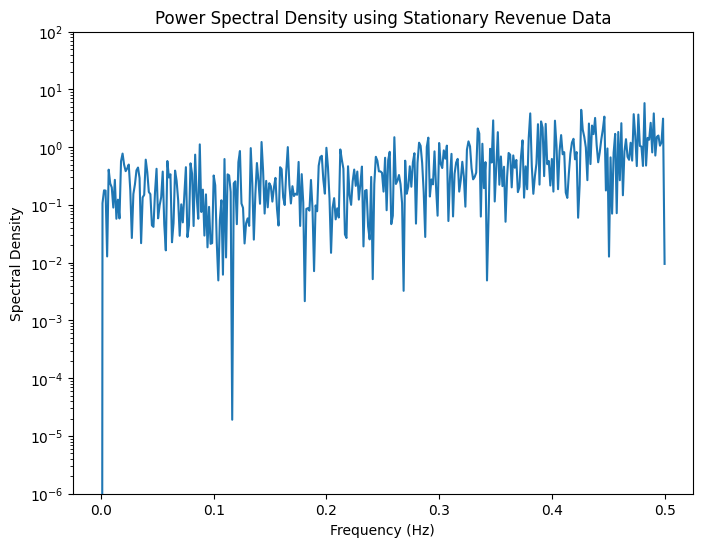

In [ ]:
# Power Spectral Density using the Stationary Data
f, Pxx_den = signal.periodogram(diff_ts)

plt.figure(figsize=(8,6))
plt.semilogy(f, Pxx_den)
plt.ylim([1e-6,1e2])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Spectral Density')
plt.title('Power Spectral Density using Stationary Revenue Data')
plt.show()

The spectral density of the stationary data centers around zero, indicating the absence of any seasonal patterns.

#### Decomposed Time Series
Decomposition provides a deeper understanding of the time series data by isolating the trend, seasonality, and residuals. 

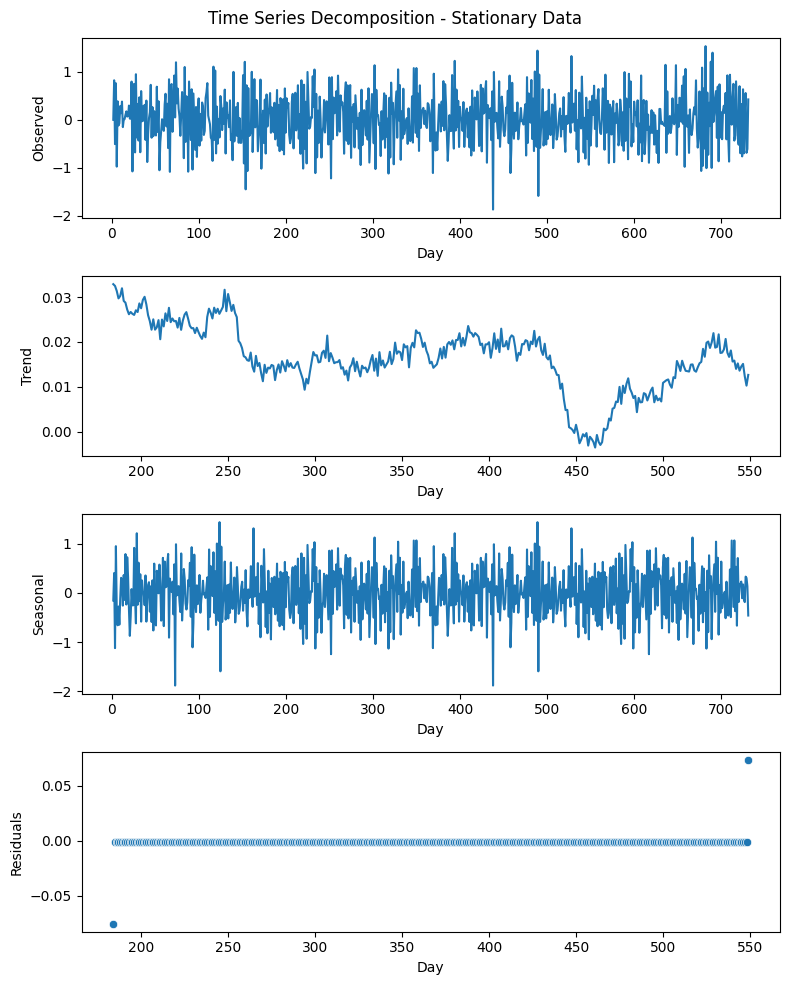

In [ ]:
# Decomposed time series - Stationary Data
# Plots trend with noise, trend without noise, seasonality, residuals
decomp_diff = seasonal_decompose(diff_ts, model='additive', period = 365)

fig, ax = plt.subplots(4, figsize = (8,10))
plt.suptitle('Time Series Decomposition - Stationary Data')
sns.lineplot(data=decomp_diff.observed, ax=ax[0])
ax[0].set_xlabel('Day')
ax[0].set_ylabel('Observed')
sns.lineplot(data=decomp_diff.trend, ax=ax[1])
ax[1].set_xlabel('Day')
ax[1].set_ylabel('Trend')
sns.lineplot(data=decomp_diff.seasonal, ax=ax[2])
ax[2].set_xlabel('Day')
ax[2].set_ylabel('Seasonal')
sns.scatterplot(data=decomp_diff.resid, ax=ax[3])
ax[3].set_xlabel('Day')
ax[3].set_ylabel('Residuals')

# Adjust layout
plt.tight_layout()
plt.savefig('Time Series Decomposition - Stationary Data.png')

#### Residuals of the Decomposed Series

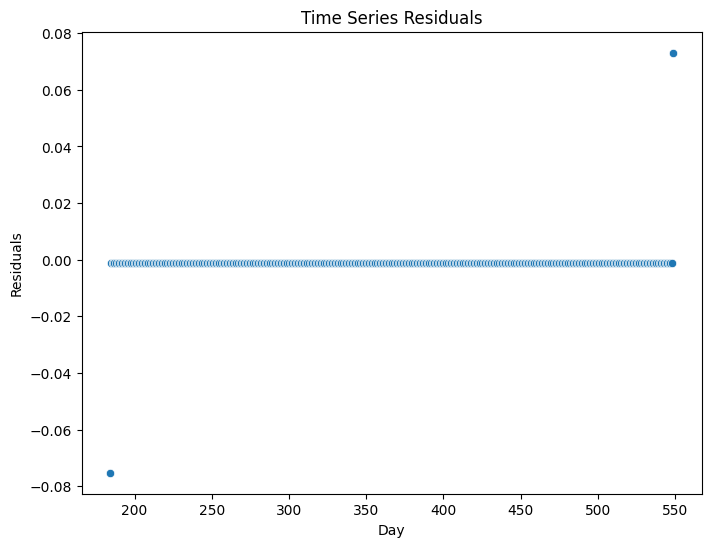

In [ ]:
# Residuals of the decomposed series - stationary data
plt.figure(figsize=(8,6))
sns.scatterplot(data=decomp_diff.resid)
plt.title('Time Series Residuals')
plt.ylabel('Residuals')
plt.show()

The residuals are centered at zero, which means that the mean is zero and the data is stationary.

In [ ]:
# Run auto_arima on original data set to check seasonality and get Python's recommended (p, d, q) values
stepwise_fit = auto_arima(ts, trace=True)
stepwise_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=987.305, Time=1.47 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1162.819, Time=0.18 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=983.122, Time=0.27 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1019.369, Time=0.30 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1162.139, Time=0.20 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=985.104, Time=0.38 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=985.106, Time=0.18 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=986.045, Time=1.33 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=984.710, Time=0.10 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0] intercept
Total fit time: 4.466 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  731
Model:               SARIMAX(1, 1, 0)   Log Likelihood                -488.561
Date:                Mon, 11 Nov 2024   AIC                            983.122
Time:                        00:18:04   BIC                            996.901
Sample:                             0   HQIC                           988.438
                                - 731                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0332      0.018      1.895      0.058      -0.001       0.068
ar.L1         -0.4692      0.033    -14.296      0.000      -0.534      -0.405
sigma2         0.2232      0.013     17.801      0.000       0.199       0.248
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 2.05
Prob(Q):                              0.96   Prob(JB):                         0.36
Heteroskedasticity (H):               1.02   Skew:                            -0.02
Prob(H) (two-sided):                  0.85   Kurtosis:                         2.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<b> Best model:  ARIMA(1,1,0)(0,0,0)[0] <br>
AIC=983.122

In [ ]:
# Run auto_arima on training data
stepwise_fit_train = auto_arima(train, trace=True)
stepwise_fit_train.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=851.096, Time=0.72 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=992.906, Time=0.15 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=847.028, Time=0.20 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=875.628, Time=0.23 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=991.543, Time=0.07 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=848.980, Time=0.25 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=848.989, Time=0.32 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=850.280, Time=1.12 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=846.716, Time=0.12 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=848.637, Time=0.15 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=848.653, Time=0.16 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=875.578, Time=0.15 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=849.696, Time=0.58 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0]          
Total fit time: 4.257 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  641
Model:               SARIMAX(1, 1, 0)   Log Likelihood                -421.358
Date:                Mon, 11 Nov 2024   AIC                            846.716
Time:                        00:18:08   BIC                            855.639
Sample:                             0   HQIC                           850.180
                                - 641                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4524      0.035    -12.962      0.000      -0.521      -0.384
sigma2         0.2184      0.013     16.662      0.000       0.193       0.244
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.88
Prob(Q):                              0.97   Prob(JB):                         0.39
Heteroskedasticity (H):               0.99   Skew:                            -0.04
Prob(H) (two-sided):                  0.94   Kurtosis:                         2.75
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### D2. ARIMA Model

In [ ]:
# Identify an ARIMA model
# From auto_arima -> Best model:  ARIMA(1,1,0)(0,0,0)[0] 
model = ARIMA(ts.reset_index(drop=True), order=(1,1,0))
model = model.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  731
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -490.355
Date:                Mon, 11 Nov 2024   AIC                            984.710
Time:                        00:18:08   BIC                            993.896
Sample:                             0   HQIC                           988.254
                                - 731                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4667      0.033    -14.213      0.000      -0.531      -0.402
sigma2         0.2243      0.013     17.782      0.000       0.200       0.249
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 2.07
Prob(Q):                              0.98   Prob(JB):                         0.36
Heteroskedasticity (H):               1.02   Skew:                            -0.02
Prob(H) (two-sided):                  0.89   Kurtosis:                         2.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
# ARIMA model
model2 = ARIMA(ts.reset_index(drop=True), order=(1,0,0))
model2 = model2.fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  731
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -582.531
Date:                Mon, 11 Nov 2024   AIC                           1171.061
Time:                        00:18:09   BIC                           1184.844
Sample:                             0   HQIC                          1176.379
                                - 731                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.4634      2.606      3.632      0.000       4.357      14.570
ar.L1          0.9945      0.004    243.683      0.000       0.986       1.002
sigma2         0.2864      0.016     17.783      0.000       0.255       0.318
===================================================================================
Ljung-Box (L1) (Q):                 159.77   Jarque-Bera (JB):                 2.13
Prob(Q):                              0.00   Prob(JB):                         0.35
Heteroskedasticity (H):               1.02   Skew:                            -0.03
Prob(H) (two-sided):                  0.87   Kurtosis:                         2.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
# ARIMA model
model3 = ARIMA(ts.reset_index(drop=True), order=(1,0,1))
model3 = model3.fit()
model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  731
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -512.076
Date:                Mon, 11 Nov 2024   AIC                           1032.152
Time:                        00:18:10   BIC                           1050.530
Sample:                             0   HQIC                          1039.242
                                - 731                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.7254      5.720      1.525      0.127      -2.486      19.937
ar.L1          0.9990      0.002    412.339      0.000       0.994       1.004
ma.L1         -0.3845      0.033    -11.512      0.000      -0.450      -0.319
sigma2         0.2359      0.013     17.836      0.000       0.210       0.262
===================================================================================
Ljung-Box (L1) (Q):                   6.62   Jarque-Bera (JB):                 1.89
Prob(Q):                              0.01   Prob(JB):                         0.39
Heteroskedasticity (H):               1.00   Skew:                             0.01
Prob(H) (two-sided):                  0.98   Kurtosis:                         2.75
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
# From auto_arima -> Best model:  ARIMA(1,1,0)(0,0,0)[0] 
modelT = ARIMA(train.reset_index(drop=True), order=(1,1,0))
modelT = modelT.fit()
modelT.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  641
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -421.358
Date:                Mon, 11 Nov 2024   AIC                            846.716
Time:                        00:18:10   BIC                            855.639
Sample:                             0   HQIC                           850.180
                                - 641                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4524      0.035    -12.962      0.000      -0.521      -0.384
sigma2         0.2184      0.013     16.662      0.000       0.193       0.244
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.88
Prob(Q):                              0.97   Prob(JB):                         0.39
Heteroskedasticity (H):               0.99   Skew:                            -0.04
Prob(H) (two-sided):                  0.94   Kurtosis:                         2.75
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
# ARIMA model
modelT2 = ARIMA(train.reset_index(drop=True), order=(1,0,0))
modelT2 = modelT2.fit()
modelT2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  641
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -496.652
Date:                Mon, 11 Nov 2024   AIC                            999.304
Time:                        00:18:10   BIC                           1012.693
Sample:                             0   HQIC                          1004.501
                                - 641                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.0768      1.871      4.317      0.000       4.410      11.744
ar.L1          0.9923      0.004    225.406      0.000       0.984       1.001
sigma2         0.2740      0.016     16.803      0.000       0.242       0.306
===================================================================================
Ljung-Box (L1) (Q):                 131.89   Jarque-Bera (JB):                 2.00
Prob(Q):                              0.00   Prob(JB):                         0.37
Heteroskedasticity (H):               0.95   Skew:                            -0.08
Prob(H) (two-sided):                  0.70   Kurtosis:                         2.78
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
# ARIMA model
modelT3 = ARIMA(train.reset_index(drop=True), order=(1,0,1))
modelT3 = modelT3.fit()
modelT3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  641
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -438.552
Date:                Mon, 11 Nov 2024   AIC                            885.104
Time:                        00:18:11   BIC                            902.956
Sample:                             0   HQIC                           892.033
                                - 641                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.7911      3.189      2.129      0.033       0.540      13.042
ar.L1          0.9981      0.002    416.797      0.000       0.993       1.003
ma.L1         -0.3763      0.035    -10.818      0.000      -0.445      -0.308
sigma2         0.2283      0.014     16.748      0.000       0.202       0.255
===================================================================================
Ljung-Box (L1) (Q):                   4.79   Jarque-Bera (JB):                 1.52
Prob(Q):                              0.03   Prob(JB):                         0.47
Heteroskedasticity (H):               0.94   Skew:                            -0.03
Prob(H) (two-sided):                  0.66   Kurtosis:                         2.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#### Comparing and Selecting the ARIMA Model with the best AIC
Original Dataset
1. Auto ARIMA on original dataset: Best Model Order 1,1,0; AIC = 983.122
2. Manual ARIMA on model: Model Order 1,1,0; AIC = 984.710
3. Manual ARIMA on model2: Model Order 1,0,0; AIC = 1171.061
4. Manual ARIMA on model3: Model Order 1,0,1; AIC = 1032.152

Training Dataset
1. Auto ARIMA on training dataset: Best Model Order 1,1,0; AIC = 846.716
2. Manual ARIMA on modelT: Model Order 1,1,0; AIC = 846.716 <b>
3. Manual ARIMA on modelT2: Model Order 1,0,0; AIC = 999.304
4. Manual ARIMA on modelT3: Model Order 1,0,1; AIC = 885.104

### D3. Forecasting using ARIMA Model

In [ ]:
# Generate Predictions 
pred = modelT.get_prediction(start=len(train), end=len(ts)+90)

<Axes: title={'center': 'Predicted Mean'}, ylabel='Revenue'>

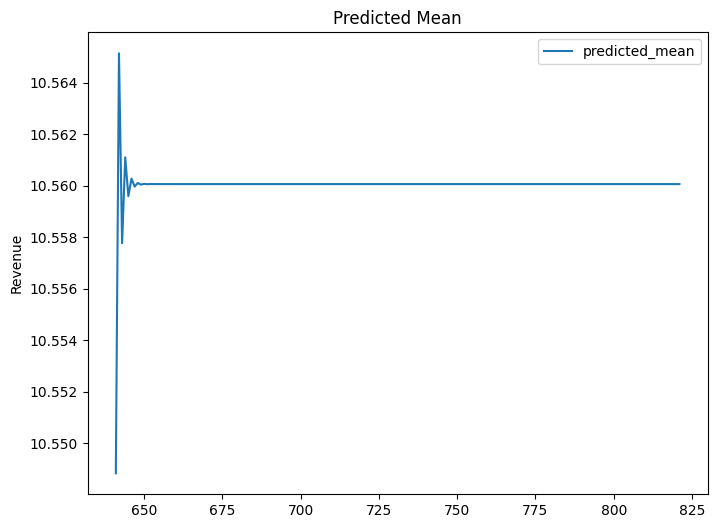

In [ ]:
plt.figure(figsize=(8,6))
plt.title('Predicted Mean')
plt.ylabel('Revenue')
pred.predicted_mean.plot(legend=True)

Text(0, 0.5, 'Revenue')

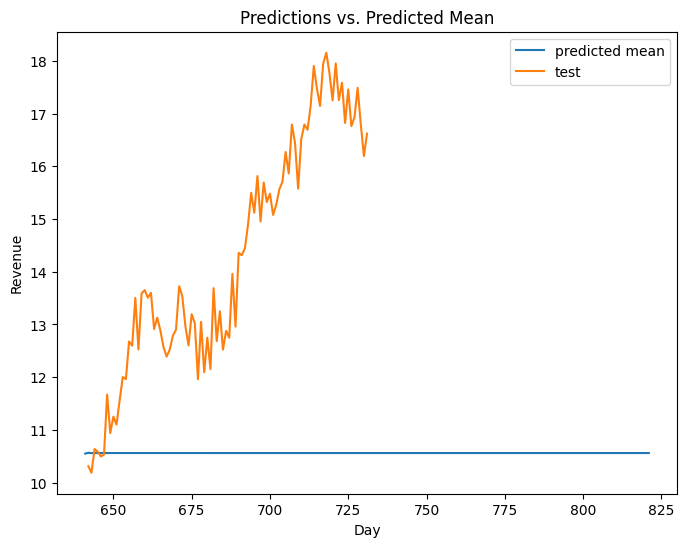

In [ ]:
plt.figure(figsize=(8,6))
pred.predicted_mean.plot(legend=True, label='predicted mean')
test.plot(legend=True, label='test')
plt.title('Predictions vs. Predicted Mean')
plt.xlabel('Day')
plt.ylabel('Revenue')

In [ ]:
# Extract Predicted Mean
pm = pred.predicted_mean

# Obtain confidence intervals
conf_int = pred.conf_int()

# Lower and Upper Limits
lower_lim = conf_int.loc[:,'lower y']
upper_lim = conf_int.loc[:,'upper y']

print(pm)
print(lower_lim)
print(upper_lim)

641    10.548830
642    10.565146
643    10.557765
644    10.561104
645    10.559593
         ...    
817    10.560064
818    10.560064
819    10.560064
820    10.560064
821    10.560064
Name: predicted_mean, Length: 181, dtype: float64
641    9.632914
642    9.520888
643    9.306679
644    9.171754
645    9.028842
         ...   
817    2.149251
818    2.125642
819    2.102100
820    2.078622
821    2.055210
Name: lower y, Length: 181, dtype: float64
641    11.464746
642    11.609404
643    11.808850
644    11.950454
645    12.090344
         ...    
817    18.970877
818    18.994485
819    19.018028
820    19.041505
821    19.064918
Name: upper y, Length: 181, dtype: float64


In [ ]:
help(pred.conf_int)

Help on method conf_int in module statsmodels.tsa.statespace.mlemodel:

conf_int(method='endpoint', alpha=0.05, **kwds) method of statsmodels.tsa.statespace.mlemodel.PredictionResults instance
    Confidence interval construction for the predicted mean.

    This is currently only available for t and z tests.

    Parameters
    ----------
    alpha : float, optional
        The significance level for the prediction interval.
        The default `alpha` = .05 returns a 95% confidence interval.

    Returns
    -------
    pi : {ndarray, DataFrame}
        The array has the lower and the upper limit of the prediction
        interval in the columns.



### D4. Output and Calculations

In [ ]:
print('Predicted Mean: ', round(pm.mean(),2))

Predicted Mean:  10.56


In [ ]:
print('Observed Mean: ', round(test.mean(),2))

Observed Mean:  14.26


In [ ]:
print('Difference: ', round(test.mean()-pm.mean(), 2))

Difference:  3.7


In [ ]:
# Root mean squared error metric - test data
rmse = sqrt(mse(pm[:90], test))
print('RMSE of Test Data:', round(rmse, 2))

RMSE of Test Data: 4.32


### E1. Results
<b>Selection of an ARIMA model: </b><br>
The ARIMA model selected had an order of (1,1,0) and an AIC score of 846.716, which was the lowest among the models tested. The choice of p=1 was based on the Partial Autocorrelation Function (PACF), which showed a significant spike at lag 1, followed by a sharp drop to zero. This indicates a strong correlation with the previous time step and minimal correlation with subsequent lags, suggesting that one autoregressive term is sufficient. For the differencing order, d=1 was chosen because a single difference was enough to make the series stationary, as confirmed by the ADF test. The Autocorrelation Function (ACF) of the original data showed slow decay, pointing to a lack of significant moving average effects, which supported the choice of q=0. After differencing, the ACF of the residuals showed that all autocorrelations fell within the confidence bounds, further confirming the choice of q=0. <br>

<b>Prediction interval of the forecast: </b><br>
The 3-month revenue forecast, based on the predicted mean, shows a stable projected trend represented by the straight horizontal line. This indicates the model’s expectation that revenue will remain steady over the forecast period. However, the widening 95% confidence interval, shown by the shaded gray area, reflects increasing uncertainty as the forecast extends further into the future. This interval suggests that while the central forecast is stable, there is a reasonable chance for revenue variability, either above or below the projected mean. This widening range highlights the forecast's limitations for long-term planning and underscores the importance of preparing for potential fluctuations within this interval.

<b>Forecast Length Justification: </b><br>
A 90-day forecast is suitable for telecom revenue data, given the 731 days of historical daily data. Telecom revenues often follow short-term patterns like monthly billing cycles, and companies typically plan on a quarterly basis. A 90-day forecast aligns with this planning and captures these trends effectively. Forecasts beyond 90 days become less accurate due to increasing uncertainty, making this timeframe ideal for reliable, actionable predictions.

<b>Evaluation of Model:</b> <br>
The root mean squared error (RMSE) metric was used to evaluate the model's predictive accuracy and ability to generalize data. The ARIMA model using the training data and model order(1,1,0) resulted in an RMSE score of 4.32. An RMSE of 4.32 tells us that, when making predictions on new data, the model’s typical deviation from the true value is about 4.32 units.

<b>Summary</b><br>
Time series forecasting with the ARIMA model can effectively predict future telecom revenue by leveraging historical trends. Here, an ARIMA(1,1,0) model was selected for its optimal fit, shown by the lowest AIC and a RMSE of 4.32. The 90-day forecast aligns with telecom’s quarterly planning cycles and captures short-term revenue trends while remaining reliable. The model projects stable revenue with a widening 95% confidence interval, indicating increasing uncertainty over time. This approach helps telecom executives anticipate revenue patterns and prepare for potential variability, supporting informed financial planning.

### E2. Annotated Visualization

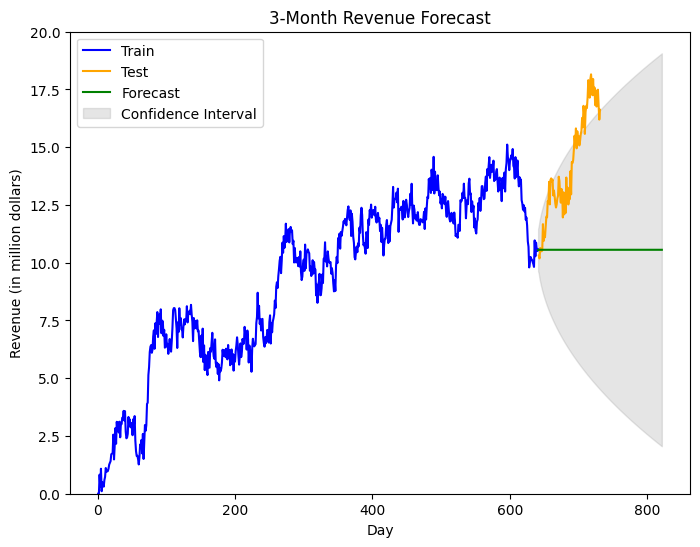

In [ ]:
# 3-month revenue forecast
plt.figure(figsize=(8,6))
plt.plot(train, label="Train", color='b')
plt.plot(test, label="Test", color='orange')
plt.plot(pm, label="Forecast", color='g')
plt.ylim([0,20])
plt.fill_between(lower_lim.index, lower_lim, upper_lim, color='grey', alpha=0.2, label='Confidence Interval')
plt.title('3-Month Revenue Forecast')
plt.xlabel('Day')
plt.ylabel('Revenue (in million dollars)')
plt.legend()
# plt.savefig('3-Month Revenue Forecast.png')

### E3. Recommendation/ Course of Action
The ARIMA model’s 3-month revenue forecast, showing a stable trend with a widening 95% confidence interval, offers telecommunications executives insights into revenue patterns and the potential impact of customer churn. While the stable trend suggests steady revenue, the expanding confidence interval highlights growing uncertainty over time. Focusing on shorter-term forecasts would likely yield more reliable results, given the reduced uncertainty. Short-term, flexible planning is advisable to adapt to potential fluctuations, and refining the model to capture seasonal or churn-related trends could improve accuracy. Regular updates will help keep the forecast relevant in a dynamic market.

### G. Sources for Third-Party Code
Elleh, F. (n.d.-a). D213 Task 1 Building Arima Model in Python video. Panopto. Retrieved November 10, 2024, from &nbsp;&nbsp;&nbsp;&nbsp;http://wgu.hosted.panopto.com/Panopto/Pages/Auth/Login.aspx?instance=WGU&Auth=SessionView&panoptoState=49a1036e-ff96-4a96-ba93-b2250064f57e

Elleh, F. (n.d.-b). D213 Webinar Task 1 Data Preprocessing Python. Panopto. Retrieved November 10, 2024, from &nbsp;&nbsp;&nbsp;&nbsp;http://wgu.hosted.panopto.com/Panopto/Pages/Auth/Login.aspx?instance=WGU&Auth=SessionView&panoptoState=96d4a431-6895-4341-af7c-b2250064c36b

Periodogram—Scipy v1. 14. 1 manual. (n.d.). Retrieved November 10, 2024, from &nbsp;&nbsp;&nbsp;&nbsp;https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.periodogram.html

Sewell, W. (n.d.). D213 Webinar Task One Arima I. Panopto. Retrieved November 10, 2024, from &nbsp;&nbsp;&nbsp;&nbsp;http://wgu.hosted.panopto.com/Panopto/Pages/Auth/Login.aspx?instance=WGU&Auth=SessionView&panoptoState=b8ac4c48-647c-4d28-b376-b2250063f3a5

Statsmodels.tsa.statespace.sarimax.SARIMAXResults.get_forecast. (n.d.). Statsmodel. &nbsp;&nbsp;&nbsp;&nbsp;https://www.statsmodels.org/dev/generated/statsmodels.tsa.statespace.sarimax.SARIMAXResults.get_prediction.html

Sewell, W. (n.d.). D213 ARIMA II Webinar. Panopto. Retrieved November 10, 2024, from http://wgu.hosted.panopto.com/Panopto/Pages/Auth/Login.aspx?&nbsp;&nbsp;&nbsp;&nbsp;instance=WGU&Auth=SessionView&panoptoState=08dd0d43-86d0-4662-9cfa-b22500645cec


### H. Sources
Elleh, F. (n.d.-a). D213 Task 1 Building Arima Model in Python video. Panopto. Retrieved November 10, 2024, from &nbsp;&nbsp;&nbsp;&nbsp;http://wgu.hosted.panopto.com/Panopto/Pages/Auth/Login.aspx?instance=WGU&Auth=SessionView&panoptoState=49a1036e-ff96-4a96-ba93-b2250064f57e

Elleh, F. (n.d.-b). D213 Webinar Task 1 Data Preprocessing Python. Panopto. Retrieved November 10, 2024, from &nbsp;&nbsp;&nbsp;&nbsp;http://wgu.hosted.panopto.com/Panopto/Pages/Auth/Login.aspx?instance=WGU&Auth=SessionView&panoptoState=96d4a431-6895-4341-af7c-b2250064c36b

Sewell, W. (n.d.). D213 Webinar Task One Arima I. Panopto. Retrieved November 10, 2024, from &nbsp;&nbsp;&nbsp;&nbsp;http://wgu.hosted.panopto.com/Panopto/Pages/Auth/Login.aspx?instance=WGU&Auth=SessionView&panoptoState=b8ac4c48-647c-4d28-b376-b2250063f3a5

Sewell, W. (n.d.). D213 ARIMA II Webinar. Panopto. Retrieved November 10, 2024, from http://wgu.hosted.panopto.com/Panopto/Pages/Auth/Login.aspx?&nbsp;&nbsp;&nbsp;&nbsp;instance=WGU&Auth=SessionView&panoptoState=08dd0d43-86d0-4662-9cfa-b22500645cec
